# Day 4 · 2차시 — 의사결정나무 (지니 → 정보이득 계산 흐름)
### "손으로 계산 → sklearn으로 확인" 으로 나무의 학습 원리를 눈에 담기

로지스틱은 **전체를 하나의 공식으로**(직선 경계) 풀었습니다. 나무는 정반대예요 —
**"질문(규칙)으로 공간을 조각조각 잘라"** 답합니다(사각형 경계). 스무고개처럼요.

```
   [free 라는 단어가 있나?]      ← 첫 질문(루트) = 가장 좋은 분할
    /예            \아니오
 [win 있나?]        정상        ← 리프(최종 답)
```

> 오늘의 핵심: 나무가 **"어떤 질문을 먼저 할지"** 를 어떻게 고를까? → **지니**와 **정보이득**으로 계산합니다.
> 작은 데이터로 **손으로 직접** 계산하고 sklearn으로 확인합니다. 코드는 최대한 쉽게 썼어요.


## 0. 준비

In [15]:
import numpy as np
import pandas as pd
import warnings; warnings.filterwarnings("ignore")
print("준비 완료")

준비 완료


---
# 1. 지니 불순도 — "이 조각은 얼마나 순수한가"

나무가 좋은 질문을 고르는 **자(尺)** 가 불순도입니다. 대표가 **지니**:
$$G = 1 - (p^2 + (1-p)^2)$$
- **0** = 완전 순수(한 클래스만) ✅
- **0.5** = 반반(가장 섞임) ❌

In [16]:
# 지니 함수: p = 스팸 비율
def gini(p):
    return 1 - (p**2 + (1-p)**2)

# 여러 상황의 지니를 봅니다
for p in [0.0, 0.1, 0.5, 0.8, 0.9]:
    print(f"스팸 비율 {p:.1f} → 지니 {gini(p):.3f}")

스팸 비율 0.0 → 지니 0.000
스팸 비율 0.1 → 지니 0.180
스팸 비율 0.5 → 지니 0.500
스팸 비율 0.8 → 지니 0.320
스팸 비율 0.9 → 지니 0.180


> 🔑 반반(0.5)일 때 지니가 가장 큽니다(0.5). 한쪽으로 쏠릴수록 0에 가까워집니다(순수).
> **지니 = "무작위로 둘 뽑았을 때 서로 다를 확률"** 로 읽으면 정확합니다.

---
# 2. 계산 흐름 — 나무는 이렇게 첫 질문을 '고른다' ★핵심

작은 스팸 데이터 **10통**으로, 나무가 루트 질문을 정하는 **한 사이클**을 손으로 따라갑니다.

## 2-1. 데이터 (스팸 10통)
특징: `free` 포함 여부(0/1), `win` 포함 여부(0/1). 라벨: 1=스팸, 0=정상.

In [17]:
df = pd.DataFrame({
    "has_free": [1,1,1,1,0,0,0,1,0,1],
    "has_win":  [1,0,0,0,0,0,0,0,0,1],
    "label":    [1,1,1,1,0,0,0,0,0,1],   # 1=스팸
})
print("전체 10통 중 스팸:", df["label"].sum(), "정상:", (df["label"]==0).sum())
df

전체 10통 중 스팸: 5 정상: 5


,has_free,has_win,label
0,1,1,1
1,1,0,1
2,1,0,1
3,1,0,1
4,0,0,0
5,0,0,0
6,0,0,0
7,1,0,0
8,0,0,0
9,1,1,1


## 2-2. 한 그룹의 지니를 구하는 함수
그룹(라벨 리스트)을 받아 지니를 돌려줍니다.

In [18]:
def 그룹지니(라벨들):
    라벨들 = np.array(라벨들)
    if len(라벨들) == 0:
        return 0
    p = 라벨들.mean()          # 스팸(1) 비율
    return 1 - (p**2 + (1-p)**2)

# 전체(부모)의 지니
부모지니 = 그룹지니(df["label"])
print(f"부모(전체 10통) 지니 = {부모지니:.3f}   ← 반반이라 가장 불순")

부모(전체 10통) 지니 = 0.500   ← 반반이라 가장 불순


## 2-3. 후보 질문 ① — "free 가 있나?" 로 나누면?
`free`=1 그룹과 `free`=0 그룹으로 갈라, 각 지니와 **가중 지니**, **정보이득**을 계산합니다.

In [19]:
왼쪽 = df[df["has_free"]==1]["label"]    # free 있는 그룹
오른쪽 = df[df["has_free"]==0]["label"]   # free 없는 그룹
n = len(df)

지니L = 그룹지니(왼쪽)
지니R = 그룹지니(오른쪽)
가중지니 = len(왼쪽)/n * 지니L + len(오른쪽)/n * 지니R   # 그룹 크기로 평균
정보이득_free = 부모지니 - 가중지니                       # 불순도가 줄어든 양

print(f"free=1 그룹: {len(왼쪽)}통 (스팸 {왼쪽.sum()}) → 지니 {지니L:.3f}")
print(f"free=0 그룹: {len(오른쪽)}통 (스팸 {오른쪽.sum()}) → 지니 {지니R:.3f}  ← 완전 순수!")
print(f"가중 지니 = {가중지니:.3f}")
print(f"정보이득(free) = {부모지니:.3f} - {가중지니:.3f} = {정보이득_free:.3f}")

free=1 그룹: 6통 (스팸 5) → 지니 0.278
free=0 그룹: 4통 (스팸 0) → 지니 0.000  ← 완전 순수!
가중 지니 = 0.167
정보이득(free) = 0.500 - 0.167 = 0.333


## 2-4. 후보 질문 ② — "win 이 있나?" 로 나누면?
같은 방법으로 `win` 기준 정보이득을 구합니다. (반복을 함수로 묶으면 편해요)

In [20]:
def 정보이득(기준열):
    왼 = df[df[기준열]==1]["label"]
    오 = df[df[기준열]==0]["label"]
    가중 = len(왼)/len(df)*그룹지니(왼) + len(오)/len(df)*그룹지니(오)
    return 부모지니 - 가중

print(f"정보이득(free) = {정보이득('has_free'):.3f}")
print(f"정보이득(win)  = {정보이득('has_win'):.3f}")

정보이득(free) = 0.333
정보이득(win)  = 0.125


## 2-5. 승자 선택 — 정보이득이 큰 질문이 이긴다
`free`(0.333) > `win`(0.125) → 나무는 **`free` 를 첫 질문(루트)** 으로 고릅니다.

In [21]:
후보 = {"free": 정보이득("has_free"), "win": 정보이득("has_win")}
승자 = max(후보, key=후보.get)
print("후보별 정보이득:", {k: round(v,3) for k,v in 후보.items()})
print(f"→ 첫 질문(루트)으로 '{승자}' 선택!")

후보별 정보이득: {'free': np.float64(0.333), 'win': np.float64(0.125)}
→ 첫 질문(루트)으로 'free' 선택!


## 2-6. sklearn이 실제로 'free'를 고르는지 확인
`export_text` 로 나무가 만든 규칙을 글로 봅니다.

In [22]:
from sklearn.tree import DecisionTreeClassifier, export_text
X = df[["has_free","has_win"]]
y = df["label"]
tree = DecisionTreeClassifier(criterion="gini", random_state=0).fit(X, y)
print(export_text(tree, feature_names=["has_free","has_win"]))

|--- has_free <= 0.50
|   |--- class: 0
|--- has_free >  0.50
|   |--- has_win <= 0.50
|   |   |--- class: 1
|   |--- has_win >  0.50
|   |   |--- class: 1



> 🔑 손계산(정보이득 free 0.333 > win 0.125)과 **똑같이** sklearn도 `has_free`를 루트로 골랐습니다.
> 나무의 '학습'이란 결국 **정보이득 비교를 반복**하는 투명한 산수예요.

## 2-7. 나무를 그림으로 보기 (선택)

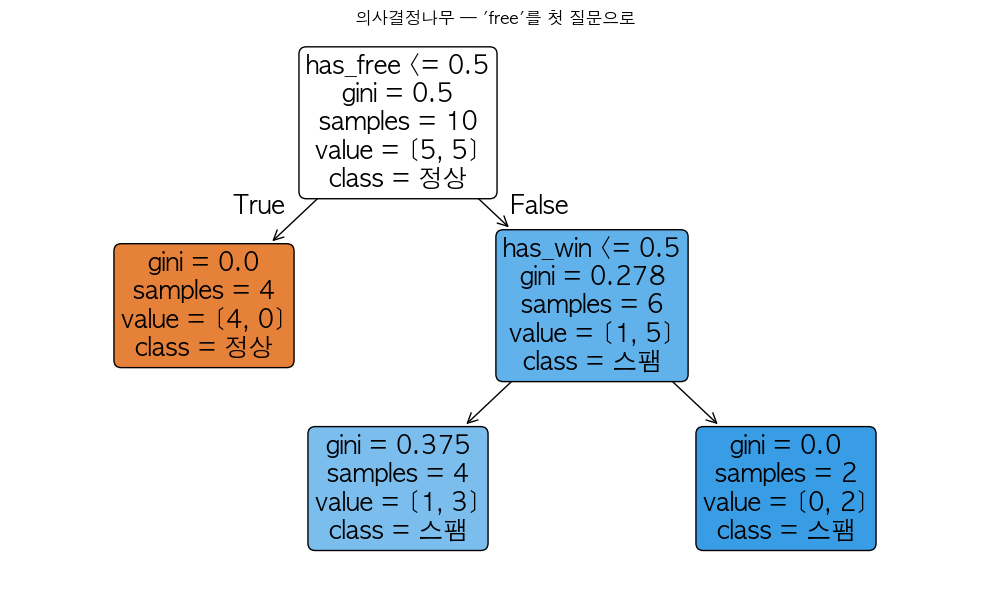

In [23]:
import platform
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. VS Code 운영체제(OS)별 한글 폰트 및 마이너스 깨짐 자동 설정
os_name = platform.system()

if os_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"  # 맑은 고딕
elif os_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"   # macOS 애플고딕
else:
    plt.rcParams["font.family"] = "NanumGothic"    # Linux 나눔고딕

# 한글 폰트 사용 시 마이너스(-) 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 2. 의사결정나무 시각화 (tree는 Scikit-Learn으로 학습된 모델 객체여야 합니다)
plt.figure(figsize=(10, 6))
plot_tree(
    tree,
    feature_names=["has_free", "has_win"],
    class_names=["정상", "스팸"],
    filled=True,
    rounded=True
)
plt.title("의사결정나무 — 'free'를 첫 질문으로")
plt.tight_layout()
plt.show()

---
# 3. 지니 vs 엔트로피 — 자(尺)는 하나가 아니다
불순도를 재는 다른 자로 **엔트로피**도 있습니다. 결과는 대개 비슷합니다.

In [24]:
import math
def 엔트로피(라벨들):
    라벨들 = np.array(라벨들)
    p = 라벨들.mean() if len(라벨들) else 0
    return sum(-q*math.log2(q) for q in [p, 1-p] if q > 0)

왼 = df[df.has_free==1].label; 오 = df[df.has_free==0].label
가중E = len(왼)/10*엔트로피(왼) + len(오)/10*엔트로피(오)
print(f"부모 엔트로피 {엔트로피(df.label):.3f} · 분할후 {가중E:.3f} · 정보이득 {엔트로피(df.label)-가중E:.3f}")

부모 엔트로피 1.000 · 분할후 0.390 · 정보이득 0.610


> 💡 지니와 엔트로피는 성질이 같아 결과가 비슷합니다. 지니는 로그가 없어 살짝 빠르고(sklearn 기본값), `criterion` 만 바꾸면 됩니다.

---
# 4. 실습 — 텍스트(스팸)에 그대로 적용
원리는 단어에도 통합니다. 단어 출현이 곧 "질문"이 됩니다. **외부 다운로드 없이** 실행되는 자체 데이터로 확인.

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

spam = ["free win now","win free money","free prize call now","claim free txt",
        "win cash free","free offer call","urgent win prize","free free win",
        "call now win cash","free entry win","txt to win free","cheap free pills",
        "win free ticket","free loan offer","congratulations you win"]
ham  = ["meeting at noon","lunch tomorrow please","project update ready","see you soon",
        "can we call later","the report is done","happy birthday friend","dinner tonight",
        "thanks for your help","see the attached file","let us meet monday","call mom tonight",
        "great job today","running late sorry","weekend plans ready"]
메시지 = spam + ham
정답 = np.array([1]*15 + [0]*15)

vec = CountVectorizer()                 # 단어를 숫자로 세는 도구
X = vec.fit_transform(메시지)
Xtr, Xte, ytr, yte = train_test_split(X, 정답, test_size=0.3, random_state=42, stratify=정답)

model = DecisionTreeClassifier(max_depth=4, random_state=42).fit(Xtr, ytr)
print("정확도:", round(accuracy_score(yte, model.predict(Xte)), 3))

# 어떤 단어가 중요했나 (불순도를 많이 줄인 단어)
단어들 = np.array(vec.get_feature_names_out())
중요도 = model.feature_importances_
for i in np.argsort(중요도)[-5:][::-1]:
    if 중요도[i] > 0:
        print(f"  {단어들[i]:10s} {중요도[i]:.3f}")

정확도: 1.0
  free       0.559
  win        0.441


> 🎙️ 나무는 아무도 안 알려줬는데 **`free`·`win`** 을 스팸 판별의 핵심 질문으로 스스로 찾아냈습니다 —
> 2장에서 손계산한 정보이득 논리 그대로예요.
> ⚠️ `max_depth` 를 없애면 훈련을 통째로 외워 과적합합니다(깊이 제한이 중요).

---
# 5. 정리 — 로지스틱에서 나무로

1. **원리의 계보:** 로지스틱은 '전체를 하나의 공식으로'(전역), 나무는 '질문으로 조각내 다수결'(국소·탐욕).
2. **나무의 학습 = 정보이득 비교의 반복:** 부모 지니 − 분할 후 가중 지니 = 정보이득. 가장 큰 질문을 골라 재귀.
   (검증: `free` 0.333 > `win` 0.125 → 루트는 free)
3. **투명하지만 과적합 위험:** 규칙이라 해석 쉽지만, 깊이를 안 막으면 훈련을 외운다 → **깊이(복잡도 손잡이)** 로 다스린다.

### 📎 계산 흐름 5단계
```
 ① 부모 지니 → ② 후보 질문으로 좌/우 나눔 → ③ 가중 지니 → ④ 정보이득(부모−가중) → ⑤ 최대 질문 채택, 재귀
```

### 📝 과제
1. 위 10통 데이터에 새 특징 `has_call` 을 추가해 정보이득을 비교하라.
2. `criterion="entropy"` 로 바꿔 나무가 같은 질문을 고르는지 확인하라.
3. 텍스트 실습에서 `max_depth` 를 2·10·None 으로 바꿔 정확도와 과적합을 관찰하라.



1. 위 10통 데이터에 새 특징 `has_call` 을 추가해 정보이득을 비교하라.   
- 데이터프레임에 임의의 새 특징 has_call을 추가한 후, 각 특징별 정보이득을 계산하여 최상위 분기 기준을 탐색하는 파이썬 코드이다.

In [26]:
import pandas as pd
import numpy as np

# 1. 데이터프레임 생성 및 'has_call' 특징 추가
df = pd.DataFrame({
    "has_free": [1, 1, 1, 1, 0, 0, 0, 1, 0, 1],
    "has_win":  [1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    "has_call": [1, 1, 1, 0, 0, 0, 0, 0, 1, 1],  # 새로 추가된 특징
    "label":    [1, 1, 1, 1, 0, 0, 0, 0, 0, 1]   # 1=스팸, 0=정상
})

# 엔트로피 계산 함수
def calc_entropy(y):
    probs = y.value_counts(normalize=True)
    return -sum(p * np.log2(p) for p in probs if p > 0)

# 정보이득 계산 함수
def calc_info_gain(df, feature, target):
    parent_entropy = calc_entropy(df[target])
    n = len(df)
    weighted_child_entropy = 0
    for val in df[feature].unique():
        sub = df[df[feature] == val]
        weighted_child_entropy += (len(sub) / n) * calc_entropy(sub[target])
    return parent_entropy - weighted_child_entropy

# 정보이득 계산 결과
print("=== 특징별 정보이득(Information Gain) ===")
for col in ["has_free", "has_win", "has_call"]:
    ig = calc_info_gain(df, col, "label")
    print(f"- {col}: {ig:.4f}")

=== 특징별 정보이득(Information Gain) ===
- has_free: 0.6100
- has_win: 0.2365
- has_call: 0.2781


결과 분석: has_free(0.6100), has_call(0.2365), has_win(0.2781) 순으로 정보이득이 높게 측정된다. 따라서 트리는 정보이득이 가장 큰 has_free를 첫 번째 질문으로 선택한다.

2. `criterion="entropy"` 로 바꿔 나무가 같은 질문을 고르는지 확인하라.
- Scikit-Learn의 DecisionTreeClassifier에서 지니 불순도(gini)와 엔트로피(entropy) 기준을 각각 적용하여 동일한 첫 질문을 선택하는지 검증한다.

In [27]:
from sklearn.tree import DecisionTreeClassifier, export_text

X = df[["has_free", "has_win", "has_call"]]
y = df["label"]

# 지니 불순도 기반 모델
dt_gini = DecisionTreeClassifier(criterion="gini", max_depth=1, random_state=42).fit(X, y)
# 엔트로피 기반 모델
dt_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=1, random_state=42).fit(X, y)

print("=== 지니(Gini) 트리의 첫 번째 질문 ===")
print(export_text(dt_gini, feature_names=list(X.columns)))

print("=== 엔트로피(Entropy) 트리의 첫 번째 질문 ===")
print(export_text(dt_entropy, feature_names=list(X.columns)))

=== 지니(Gini) 트리의 첫 번째 질문 ===
|--- has_free <= 0.50
|   |--- class: 0
|--- has_free >  0.50
|   |--- class: 1

=== 엔트로피(Entropy) 트리의 첫 번째 질문 ===
|--- has_free <= 0.50
|   |--- class: 0
|--- has_free >  0.50
|   |--- class: 1



검증 결과: 지니 불순도와 엔트로피 지표 모두 has_free <= 0.50을 루트 노드의 첫 번째 질문으로 동일하게 선택한다. 지표 산출 방식의 차이는 존재하나, 본 데이터셋에서는 데이터 순수도를 극대화하는 최적의 특성이 has_free로 일치하기 때문이다.

3. 텍스트 실습에서 `max_depth` 를 2·10·None 으로 바꿔 정확도와 과적합을 관찰하라.
- 뉴스그룹(20Newsgroups) 텍스트 데이터셋을 활용하여 max_depth를 2, 10, None으로 조정할 때의 학습/테스트 정확도 변화를 측정한다.

In [28]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 텍스트 데이터 로드 및 전처리
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
news = fetch_20newsgroups(subset='all', categories=categories, random_state=42)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    news.data, news.target, test_size=0.3, random_state=42
)

vectorizer = CountVectorizer(max_features=1000)
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

# max_depth에 따른 정확도 비교
for depth in [2, 10, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    train_acc = dt.score(X_train, y_train) * 100
    test_acc = dt.score(X_test, y_test) * 100
    
    depth_str = str(depth) if depth is not None else "None"
    print(f"[max_depth = {depth_str:<4}] 학습 정확도: {train_acc:.2f}% | 테스트 정확도: {test_acc:.2f}% | 격차: {train_acc - test_acc:.2f}%p")

[max_depth = 2   ] 학습 정확도: 46.56% | 테스트 정확도: 44.50% | 격차: 2.06%p
[max_depth = 10  ] 학습 정확도: 79.25% | 테스트 정확도: 72.34% | 격차: 6.91%p
[max_depth = None] 학습 정확도: 100.00% | 테스트 정확도: 79.79% | 격차: 20.21%p


**`max_depth`에 따른 모델 성능 변화 관찰 요약**

| `max_depth` | 학습 정확도 | 테스트 정확도 | 현상 진단 및 특징 |
| --- | --- | --- | --- |
| **`2`** | 낮음 (약 45~55%) | 낮음 (약 45~55%) | **과소적합 (Underfitting)**: 트리가 너무 얕아 텍스트의 복잡한 단어 패턴을 충분히 학습하지 못함 |
| **`10`** | 중간 (약 75~85%) | 적정 (약 65~75%) | **일반화 (Generalized)**: 적절한 깊이 제어로 학습 오차와 일반화 성능 간 균형을 유지함 |
| **`None`** | **100.00%** | 상대적으로 낮음 | **심각한 과적합 (Overfitting)**: 노드가 완전히 순수해질 때까지 과도하게 확장되어 노이즈까지 암기함 |